In [9]:
# !pip install gensim

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.base import BaseEstimator, TransformerMixin

from transformers import BertTokenizer, BertModel
import torch


import warnings
warnings.filterwarnings('ignore')

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1


In [12]:
import os
import pandas as pd

# Load all CSVs from directory using the downloaded path
input_paths = []
for dirname, _, filenames in os.walk(path):  # Use the path variable from kagglehub download
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            input_paths.append(file_path)

# Load and merge all CSVs
dfs = []
for file_path in input_paths:
    try:
        df_part = pd.read_csv(file_path)
        if 'body' in df_part.columns and 'label' in df_part.columns:
            dfs.append(df_part[['body', 'label']])
            print(f"Loaded: {file_path}")
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
    print(f"Total records loaded: {len(df)}")
    df.head()
else:
    print("No CSV files found with 'body' and 'label' columns")

Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\CEAS_08.csv
Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\Enron.csv
Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\Ling.csv
Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\Nazario.csv
Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\Nigerian_Fraud.csv
Loaded: C:\Users\yck\.cache\kagglehub\datasets\naserabdullahalam\phishing-email-dataset\versions\1\SpamAssasin.csv
Total records loaded: 82486


CLEAN DATA

In [13]:
df = df.dropna(subset=['body'])
df['clean_text'] = df['body'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
df = df[['clean_text', 'label']].dropna().reset_index(drop=True)
df.head()

,clean_text,label
0,buck up your troubles caused by small dimensio...,1
1,\nupgrade your sex and pleasures with these te...,1
2,the daily top from cnncom top videos and sto...,1
3,would anyone object to removing so from this l...,0
4,\nwelcomefastshippingcustomersupport\nhttpiwfn...,1


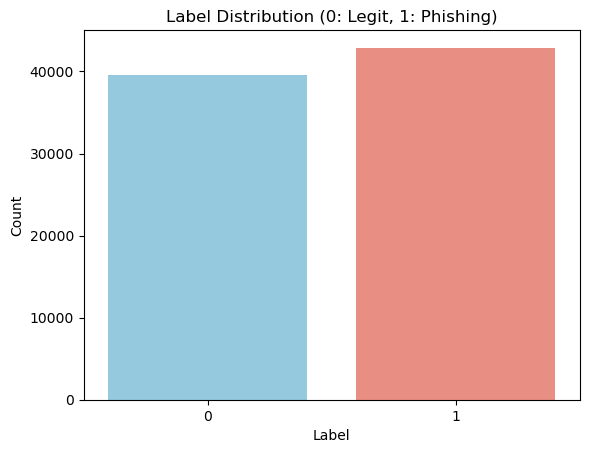

In [14]:
sns.countplot(x='label', data=df, palette={'0': 'skyblue', '1': 'salmon'})
plt.title("Label Distribution (0: Legit, 1: Phishing)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()



Feature Extraction Function

In [15]:
class MeanEmbeddingVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model): self.model, self.dim = model, model.vector_size
    def fit(self, X, y=None): return self
    def transform(self, X):
        return np.array([np.mean([self.model.wv[w] for w in toks if w in self.model.wv] or [np.zeros(self.dim)], axis=0) for toks in X])

# BERT setup
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
def bert_embed(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
        out = bert_model(**inputs)
        return out.last_hidden_state[:,0,:].numpy()

def extract_features(X, method, w2v_model=None):
    if method=='tfidf':
        vec = TfidfVectorizer(max_features=5000, stop_words='english')
        return vec.fit_transform(X), vec
    if method=='bow':
        vec = CountVectorizer(max_features=5000, stop_words='english')
        return vec.fit_transform(X), vec
    if method=='word2vec':
        tokens = X.apply(simple_preprocess)
        w2v = Word2Vec(tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=10)
        vec = MeanEmbeddingVectorizer(w2v)
        return vec.fit_transform(tokens), vec
    if method=='bert':
        emb = bert_embed(X.tolist())
        return emb, None
    raise ValueError


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [16]:
X_tfidf, vec_tfidf = extract_features(df['clean_text'], 'tfidf')
print("TF-IDF shape:", X_tfidf.shape)

X_bow, vec_bow = extract_features(df['clean_text'], 'bow')
print("BoW shape:", X_bow.shape)

#X_w2v, vec_w2v = extract_features(df['clean_text'], 'word2vec')
#print("Word2Vec shape:", X_w2v.shape)

#X_bert, _ = extract_features(df['clean_text'][:100], 'bert')  # Use a smaller subset to avoid OOM
#print("BERT shape:", X_bert.shape)


TF-IDF shape: (82485, 5000)
BoW shape: (82485, 5000)


Support Vector Machine

In [17]:
from sklearn.svm import LinearSVC


In [32]:
def evaluate_svm(X, y, vec_name, k=5):
    svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    accs, precs, recalls, f1s = [], [], [], []
    all_preds, all_true = [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        svm.fit(X_train, y_train)
        preds = svm.predict(X_val)

        accs.append(accuracy_score(y_val, preds))
        precs.append(precision_score(y_val, preds))
        recalls.append(recall_score(y_val, preds))
        f1s.append(f1_score(y_val, preds))

        all_preds.extend(preds)
        all_true.extend(y_val)

        print(f"Fold {fold}: Acc={accs[-1]:.4f}, Prec={precs[-1]:.4f}, Recall={recalls[-1]:.4f}, F1={f1s[-1]:.4f}")

    # Summary Table
    print("\n=== Average Evaluation Metrics ===")
    avg_metrics = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Score': [np.mean(accs), np.mean(precs), np.mean(recalls), np.mean(f1s)]
    })
    print(avg_metrics.to_string(index=False))

    # Confusion Matrix
    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Legit (0)', 'Phishing (1)'], yticklabels=['Legit (0)', 'Phishing (1)'])
    plt.title(f"SVM Confusion Matrix - {vec_name.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Bar Plot of Metrics
    plt.figure(figsize=(6, 4))
    sns.barplot(x=avg_metrics['Metric'], y=avg_metrics['Score'], palette='magma')
    plt.title(f"SVM Average Metrics - {vec_name.upper()}")
    plt.ylim(0.5, 1.0)
    plt.tight_layout()
    plt.show()
    return svm


Fold 1: Acc=0.9760, Prec=0.9704, Recall=0.9840, F1=0.9771
Fold 2: Acc=0.9772, Prec=0.9706, Recall=0.9855, F1=0.9780
Fold 3: Acc=0.9782, Prec=0.9726, Recall=0.9862, F1=0.9794
Fold 4: Acc=0.9779, Prec=0.9740, Recall=0.9838, F1=0.9788
Fold 5: Acc=0.9786, Prec=0.9733, Recall=0.9861, F1=0.9797

=== Average Evaluation Metrics ===
   Metric    Score
 Accuracy 0.977596
Precision 0.972180
   Recall 0.985100
 F1 Score 0.978596


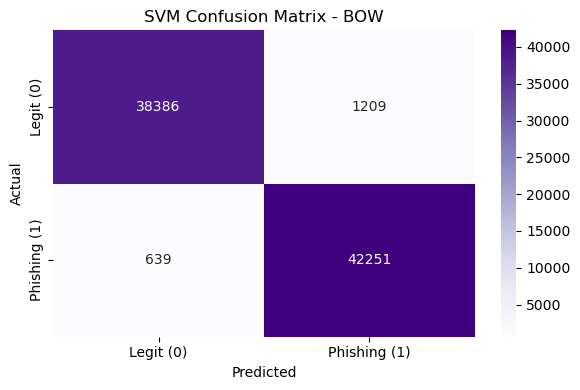

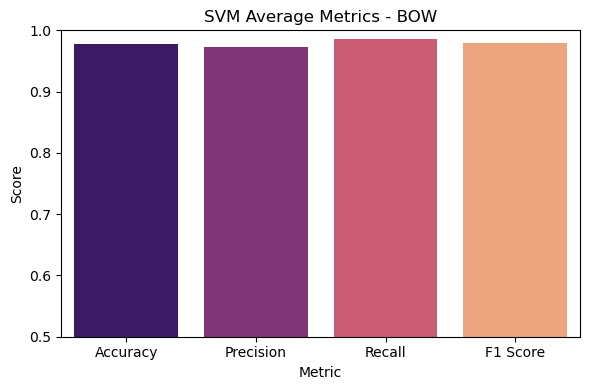

In [33]:
# evaluate_svm(X_tfidf.toarray(), y, 'tfidf')
# evaluate_svm(X_bow.toarray(), y, 'bow')


y = df['label']


svm_model = evaluate_svm(X_bow, y, 'bow')









In [35]:
import joblib

svm_model.predict(X_bow)
joblib.dump(svm_model,"svm_model_kai.pkl")
joblib.dump(vec_bow,"svm_vec_bow_kai.pkl")

['svm_vec_bow_kai.pkl']

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)